<a href="https://colab.research.google.com/github/Yahir-7/GeoPandas/blob/main/PRISM_Extreme_Heat_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

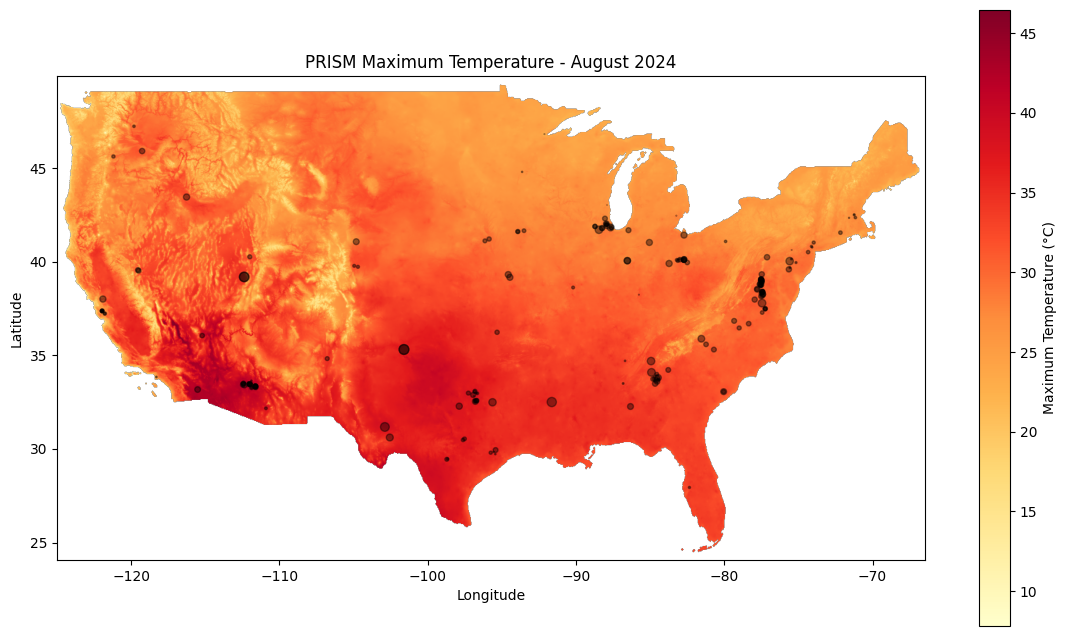

In [2]:
#!pip install rasterio geopandas pandas matplotlib

# Link used to download data for temperatures: https://prism.oregonstate.edu/data/
# August 2024 data
# Link to download locations of data centers: https://www.aterio.io/datasets/lst_us_data_centers
# Download free sample and open the excel file using pandas
# Documentation for rasterio: https://rasterio.readthedocs.io/en/stable/

import rasterio
import geopandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from rasterio.plot import show

dc = pd.read_excel("/content/Aterio US Data Centers Dashboard.xlsx", sheet_name = "Data Sample")
dc = dc[
    [
        "DATA_CENTER_BUILDING_NAME",
        "PROVIDER_NAME",
        "DATA_CENTER_STAGE",
        "FULL_ADDRESS",
        "CITY_NAME",
        "STATE_NAME",
        "LOCATION_LATITUDE",
        "LOCATION_LONGITUDE",
        "SELECTED_POWER_CAPACITY_MW",
        "DATA_CENTER_ACTIVATION_DATE",
        "DATA_CENTER_ANNOUNCED_DATE",
        "RECORD_UPDATED_DATE"
    ]
]
dc = dc.dropna(subset=["LOCATION_LATITUDE", "LOCATION_LONGITUDE"])
data_centers = geopandas.GeoDataFrame(
    dc, geometry=geopandas.points_from_xy(dc.LOCATION_LONGITUDE, dc.LOCATION_LATITUDE),
    crs= "EPSG:4326"
)

with rasterio.open("/content/prism_tmax_us_25m_202408.tif") as dataset:
    temp = dataset.read(1)
    temp = np.where(temp == -9999,np.nan, temp)

    fig, ax = plt.subplots(figsize=(14, 8))
    img = ax.imshow(
        temp,
        extent=[
            dataset.bounds.left,
            dataset.bounds.right,
            dataset.bounds.bottom,
            dataset.bounds.top
        ],
        cmap="YlOrRd"
    )

    plt.colorbar(img, ax=ax, label="Maximum Temperature (°C)")
    plt.title("PRISM Maximum Temperature - August 2024")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    data_centers.plot (
        ax = ax, markersize = dc["SELECTED_POWER_CAPACITY_MW"]/ 5,
        alpha = 0.4,
        color = "black",
        legend = True,
        legend_kwds = {"label" : "Data Center Locations"}

    )
    plt.show()
